In [31]:
"""
Pipeline complet d'analyse vibratoire supervisée
- Feature engineering glissante (rolling) -> XGBoost (classique supervisé)
- Modèle séquentiel LSTM/GRU utilisant uniquement la série 'Vibration Level (mm/s)'

Dépendances:
pip install pandas numpy scikit-learn xgboost matplotlib seaborn tensorflow joblib

"""

import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_recall_curve, roc_auc_score, average_precision_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json

# XGBoost
from xgboost import XGBClassifier

# TensorFlow pour LSTM/GRU
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

In [1]:
# -------------------------
# Configuration
# -------------------------
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ziya07/smart-manufacturing-iot-cloud-monitoring-dataset")

print("Path to dataset files:", path)

CSV_PATH = "C:\\Users\\sarrj\\Documents\\Mes doc\\Doc\\Articles\\vibrations_ana_ds.csv" 
TIME_COL = "created_at"
VIB_COL = "Vibration Level (mm/s)"
RESAMPLE_FREQ = "5min"  # 5 minutes
#SEQ_LEN = 60           # longueur de la fenêtre pour LSTM (60*5min = 5h)
#HORIZON = 144          # horizon prédictif en pas (144*5min = 12h)
ROLL_WINDOWS = [3, 6, 12, 24]  # fenêtres en nombre de pas (ex: 3*5min=15min)
TEST_SIZE_RATIO = 0.10  # dernier 10% en test
VAL_SIZE_RATIO = 0.15   # portion validation du training
RANDOM_SEED = 42

# Colonnes numériques à considérer pour features si présentes
NUM_COLS = [
    "Machine Temperature (C)",
    "Power Consumption (kW)",
    "Oil Level (%)",
    "Machine Efficiency (%)",
    "Downtime (mins)",
    "Maintenance Alerts (Count)",
    "Latitude",
    "Longitude"
]

ModuleNotFoundError: No module named 'kagglehub'

In [36]:
# -------------------------
# Helpers
# -------------------------

def charge_et_sample(csv_path = CSV_PATH):
    df = pd.read_csv(csv_path, parse_dates = [TIME_COL])
    df = df.sort_values(TIME_COL).set_index(TIME_COL)
    # resample to ensure regular grid (mean for numeric fields)
   # df = df.resample(RESAMPLE_FREQ).mean()
    # interpolate small gaps
    df = df.interpolate(method = "time")
    return df


def creer_target(df, horizon = HORIZON, downtime_thresh = 1):
    """Crée une target binaire:
       1 si dans la fenêtre future de taille `horizon` il y a Maintenance Alerts > 0
       ou Downtime >= downtime_thresh.
    """
    future_alert = df["Maintenance Alerts (Count)"].rolling(window=horizon, min_periods=1).max().shift(-horizon+1)
    future_downtime = df["Downtime (mins)"].rolling(window=horizon, min_periods=1).max().shift(-horizon+1)
    tgt = ((future_alert.fillna(0) > 0) | (future_downtime.fillna(0) >= downtime_thresh)).astype(int)
    return tgt


def creer_features(df, vib_col=VIB_COL, windows=ROLL_WINDOWS):
    """Génère des caractéristiques glissantes à partir de la colonne vibration et autres numerical columns si présentes."""
    out = pd.DataFrame(index=df.index)
    # features basiques de vibration
    out[f"vib"] = df[vib_col]
    for w in windows:
        out[f"vib_mean_{w}"] = df[vib_col].rolling(window=w, min_periods=1).mean()
        out[f"vib_std_{w}"] = df[vib_col].rolling(window=w, min_periods=1).std().fillna(0)
        out[f"vib_min_{w}"] = df[vib_col].rolling(window=w, min_periods=1).min()
        out[f"vib_max_{w}"] = df[vib_col].rolling(window=w, min_periods=1).max()
        out[f"vib_skew_{w}"] = df[vib_col].rolling(window=w, min_periods=1).skew().fillna(0)
        out[f"vib_kurt_{w}"] = df[vib_col].rolling(window=w, min_periods=1).kurt().fillna(0)
        # count of times above threshold within window
        out[f"vib_count_gt_7_{w}"] = (df[vib_col].rolling(window=w, min_periods=1).apply(lambda x: np.sum(x>7.0))).fillna(0)

    # dérivées
    out['vib_diff'] = df[vib_col].diff().fillna(0)
    out['vib_diff2'] = df[vib_col].diff().diff().fillna(0)

    # Autres colonnes numériques (moyennes & deltas)
    for col in NUM_COLS:
        if col in df.columns:
            out[f"{col}_mean_6"] = df[col].rolling(window=6, min_periods=1).mean()
            out[f"{col}_std_6"] = df[col].rolling(window=6, min_periods=1).std().fillna(0)
            out[f"{col}_diff"] = df[col].diff().fillna(0)

    # features temporelles (heure/jour)
    out['hour'] = out.index.hour
    out['dayofweek'] = out.index.dayofweek
    out['month'] = out.index.month

    return out


def preparer_tab_dataset(df_features, target):
    """Joint features et target, retire les na issues du shifting, retourne X, y et index."""
    df = df_features.copy()
    df['target'] = target
    # Supp lignes avec target is NaN (fin de la série à cause du shift)
    df = df[~df['target'].isna()]
    X = df.drop(columns=['target'])
    y = df['target'].astype(int)
    return X, y, df.index



In [37]:
# -------------------------
# XGBoost pipeline
# -------------------------

def entrainer_xgb(X_train, y_train, X_val, y_val, save_path="xgb_model.json"):
    # simple classifier xgboost
    # handle class imbalance via scale_pos_weight
    pos = y_train.sum()
    neg = len(y_train) - pos
    scale_pos_weight = (neg / pos) if pos>0 else 1.0

    clf = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        use_label_encoder=False,
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_SEED
    )

    clf.fit(
        X_train, y_train,
        early_stopping_rounds=20,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    clf.save_model(save_path)
    return clf


def evaluer_classifier(clf, X, y, name="model"):
    preds_proba = clf.predict_proba(X)[:,1]
    preds = (preds_proba > 0.5).astype(int)
    roc = roc_auc_score(y, preds_proba) if len(np.unique(y))>1 else np.nan
    ap = average_precision_score(y, preds_proba) if len(np.unique(y))>1 else np.nan
    print(f"=== Evaluation {name} ===")
    print(f"ROC AUC: {roc:.4f}")
    print(f"PR AUC (Average Precision): {ap:.4f}")
    print(classification_report(y, preds, digits=4))
    print(confusion_matrix(y, preds))
    return {'roc_auc':roc, 'ap':ap}



[1] Chargement et resampling


C:\Users\sarrj\AppData\Local\Temp\ipykernel_45200\2881888959.py:11: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.interpolate(method = "time")


[2] Création de la target
[3] Feature engineering glissant
[4] Préparation dataset tabulaire pour XGBoost
Taille train/val/test: (77, 52) (13, 52) (10, 52)
[5] Entraînement XGBoost


C:\Users\sarrj\AppData\Local\anaconda3\envs\article_ucad\Lib\site-packages\xgboost\sklearn.py:889: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


[6] Évaluation XGBoost
=== Evaluation xgb_train ===
ROC AUC: nan
PR AUC (Average Precision): nan
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        77

    accuracy                         1.0000        77
   macro avg     1.0000    1.0000    1.0000        77
weighted avg     1.0000    1.0000    1.0000        77

[[77]]
=== Evaluation xgb_val ===
ROC AUC: nan
PR AUC (Average Precision): nan
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        13

    accuracy                         1.0000        13
   macro avg     1.0000    1.0000    1.0000        13
weighted avg     1.0000    1.0000    1.0000        13

[[13]]
=== Evaluation xgb_test ===
ROC AUC: nan
PR AUC (Average Precision): nan
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        10

    accuracy                         1.0000        10
   macro avg     1.0000    1.0000 

C:\Users\sarrj\AppData\Local\anaconda3\envs\article_ucad\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
C:\Users\sarrj\AppData\Local\anaconda3\envs\article_ucad\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
C:\Users\sarrj\AppData\Local\anaconda3\envs\article_ucad\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


Saved xgb_feature_importance.png


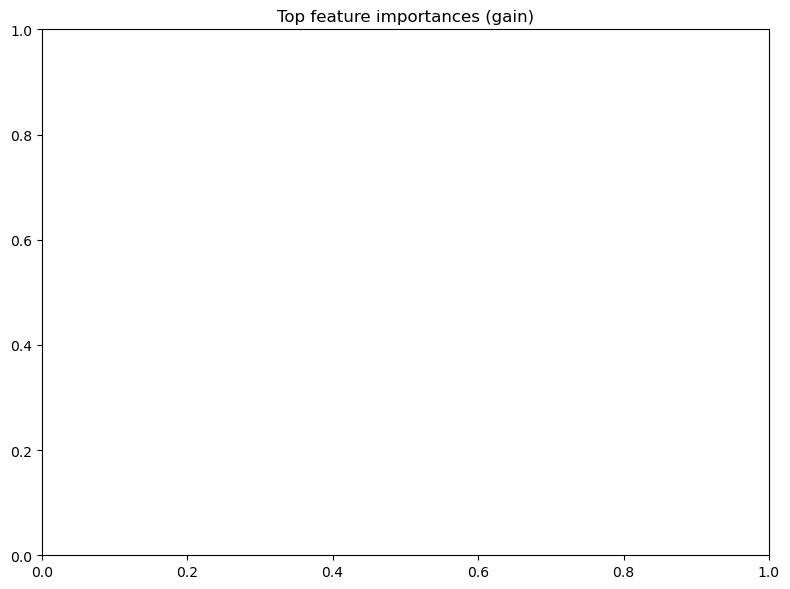

In [38]:
# -------------------------
# Main
# -------------------------
if __name__ == '__main__':
    np.random.seed(RANDOM_SEED)
    tf.random.set_seed(RANDOM_SEED)

    if not os.path.exists(CSV_PATH):
        raise FileNotFoundError(f"CSV not found: {CSV_PATH}")

    print("[1] Chargement et resampling")
    df = charge_et_sample(CSV_PATH)

    print("[2] Création de la target")
    df['target'] = creer_target(df)

    print("[3] Feature engineering glissant")
    df_feat = creer_features(df)

    print("[4] Préparation dataset tabulaire pour XGBoost")
    X, y, idx = preparer_tab_dataset(df_feat, df['target'])

    # split chronologique: dernier TEST_SIZE_RATIO en test
    n = len(X)
    test_n = int(n * TEST_SIZE_RATIO)
    X_trainval = X.iloc[:-test_n]
    y_trainval = y.iloc[:-test_n]
    X_test = X.iloc[-test_n:]
    y_test = y.iloc[-test_n:]

    # further split train/val chronologically
    val_n = int(len(X_trainval) * VAL_SIZE_RATIO)
    X_train = X_trainval.iloc[:-val_n]
    y_train = y_trainval.iloc[:-val_n]
    X_val = X_trainval.iloc[-val_n:]
    y_val = y_trainval.iloc[-val_n:]

    print("Taille train/val/test:", X_train.shape, X_val.shape, X_test.shape)

    # scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    joblib.dump(scaler, 'scaler_tabular.joblib')

    print("[5] Entraînement XGBoost")
    xgb = entrainer_xgb(X_train_scaled, y_train.values, X_val_scaled, y_val.values, save_path='xgb_model.json')

    print("[6] Évaluation XGBoost")
    res_train = evaluer_classifier(xgb, X_train_scaled, y_train.values, name='xgb_train')
    res_val = evaluer_classifier(xgb, X_val_scaled, y_val.values, name='xgb_val')
    res_test = evaluer_classifier(xgb, X_test_scaled, y_test.values, name='xgb_test')

    # Feature importance
    try:
        fi = xgb.get_booster().get_score(importance_type='gain')
        fi_items = sorted(fi.items(), key=lambda x: x[1], reverse=True)[:20]
        names = [k for k,v in fi_items]
        vals = [v for k,v in fi_items]
        plt.figure(figsize=(8,6))
        sns.barplot(x=vals, y=names)
        plt.title('Top feature importances (gain)')
        plt.tight_layout()
        plt.savefig('xgb_feature_importance.png')
        print('Saved xgb_feature_importance.png')
    except Exception as e:
        print("Impossible d'extraire features: ", e)